## Fine-tuning Qwen 3.5 0.8B
A notebook to fine-tune a model using Unsloth and save the resulting LoRA adapters.

#### Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["HF_HUB_OFFLINE"] = "1"

from dotenv import load_dotenv
load_dotenv()
SYSTEM_PROMPT = os.getenv("SYSTEM_PROMPT") 

import torch
from datasets import load_dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## Overfit Test
Ensure the model can actually learn from memorizing a small overfit dataset (`./data/overfit/train.jsonl`). The model should reach 100% accuracy.

Data format for `./data/echobot/` files:
```
id       → bookkeeping
query    → model input
label    → training target
source   → provenance
tag      → metadata / analysis
```

In [2]:
# sys prompt + user query + assistant response < max_seq_length
max_seq_length = 2048

model, tokenizer= FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen3.5-0.8B",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
    full_finetuning = False,
    dtype = torch.bfloat16,
    device_map= "auto",
)

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


==((====))==  Unsloth 2026.8.12: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100 80GB PCIe. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 8.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

In [3]:
train_path = "../data/overfit/train.jsonl"
val_path = "../data/echobot/val.jsonl"
test_path = "../data/overfit/train.jsonl"

dataset = load_dataset(
    "json",
    data_files={
        "train": train_path,
        "validation": val_path,
        "test": test_path,
    },
)
print(dataset['train'].features)

{'id': Value('string'), 'query': Value('string'), 'label': Value('int64'), 'source': Value('string'), 'tag': Value('string')}


In [4]:
def formatting_func(sample):
    return {
        "prompt": (
            f"{SYSTEM_PROMPT}\n"
            f"User query: {sample['query']}\n"
            "Classification: "
        ),
        "completion": str(sample['label'])
    }

In [5]:
from collections import Counter

# format dataset with only 'prompt' and 'completion' collumns
formatted_train = dataset["train"].map(
    formatting_func,
    remove_columns=dataset["train"].column_names
    )
formatted_val = dataset["validation"].map(
    formatting_func,
    remove_columns=dataset["validation"].column_names
    )
formatted_test = dataset["test"].map(
    formatting_func,
    remove_columns=dataset["test"].column_names
    )

print(Counter(formatted_train["completion"]))
print(Counter(formatted_val["completion"]))
print(Counter(formatted_test["completion"]))


Map:   0%|          | 0/432 [00:00<?, ? examples/s]

Map:   0%|          | 0/8 [00:00<?, ? examples/s]

Map:   0%|          | 0/432 [00:00<?, ? examples/s]

Counter({'0': 216, '1': 216})
Counter({'0': 4, '1': 4})
Counter({'0': 216, '1': 216})


```
Transformer block
│
├── Attention
│   ├── q_proj
│   ├── k_proj
│   ├── v_proj
│   └── o_proj
│
└── MLP
    ├── gate_proj
    ├── up_proj
    └── down_proj
```

In [6]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 8,
    lora_alpha = 8,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],

    finetune_vision_layers = False,
    finetune_language_layers = True, 
    finetune_attention_modules = True,
    finetune_mlp_modules = True,

    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",

    random_state = 8,
    max_seq_length = max_seq_length,
)

Unsloth: Explicit target_modules are constrained by the finetune_(vision|language|attention|mlp) filters; adapters attach only where both select.


In [7]:
trainer = SFTTrainer(
    model=model,
    train_dataset=formatted_train,
    # eval_dataset=formatted_val,
    processing_class=tokenizer,

    args=SFTConfig(
        max_seq_length=max_seq_length,
        completion_only_loss=True,

        per_device_train_batch_size=8,
        gradient_accumulation_steps=4,
        warmup_steps=10,
        num_train_epochs=5,
        optim="adamw_8bit",

        seed=8,
        dataset_num_proc=1,

        output_dir="checkpoints/outputs_qwen35_overfit",
        logging_steps=1,
    ),
)

Unsloth: Tokenizing ["prompt"+"completion"]:   0%|          | 0/432 [00:00<?, ? examples/s]

SFTTrainer loaded data information:
```
input_ids
    ↓
"What information does the model receive?"

attention_mask
    ↓
"Which positions are real tokens rather than padding?"

labels
    ↓
"Which next-token predictions should I grade,
 and what is the correct answer?"
```

In [8]:
def inspect_sfttrainer_data(trainer):
    batch = next(iter(trainer.get_train_dataloader()))

    print(f"{batch.keys()=}")
    print()
    print(f"{batch['input_ids']=}")
    print()
    print(f"{batch['labels']=}")
    print()
    print(f"{batch['attention_mask']=}")
    print()
    print("-"*100)
    print()

    input_ids = batch["input_ids"][0]
    labels = batch["labels"][0]

    for token_id, label in zip(input_ids, labels):
        token = tokenizer.decode([token_id])
        print(f"{token!r:20} {label}")

In [9]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 432 | Num Epochs = 5 | Total steps = 70
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 3,194,880 of 856,180,800 (0.37% trained)


Step,Training Loss
1,2.409400
2,2.577120
3,2.439342
4,2.593950
5,2.405658
6,2.454208
7,2.258396
8,2.000149
9,1.602986
10,1.186377


/home/mkpuzon/code/fine-tuning/.venv/lib/python3.13/site-packages/peft/utils/save_and_load.py:438: UserWarning: Could not find a config file in Qwen/Qwen3.5-0.8B - will assume that the vocabulary was not modified.
  warnings.warn(
Unsloth: Restored added_tokens_decoder metadata in checkpoints/outputs_qwen35_overfit/checkpoint-70/tokenizer_config.json.


TrainOutput(global_step=70, training_loss=0.38658073461904546, metrics={'train_runtime': 96.8403, 'train_samples_per_second': 22.305, 'train_steps_per_second': 0.723, 'total_flos': 650994005431296.0, 'train_loss': 0.38658073461904546, 'epoch': 5.0})

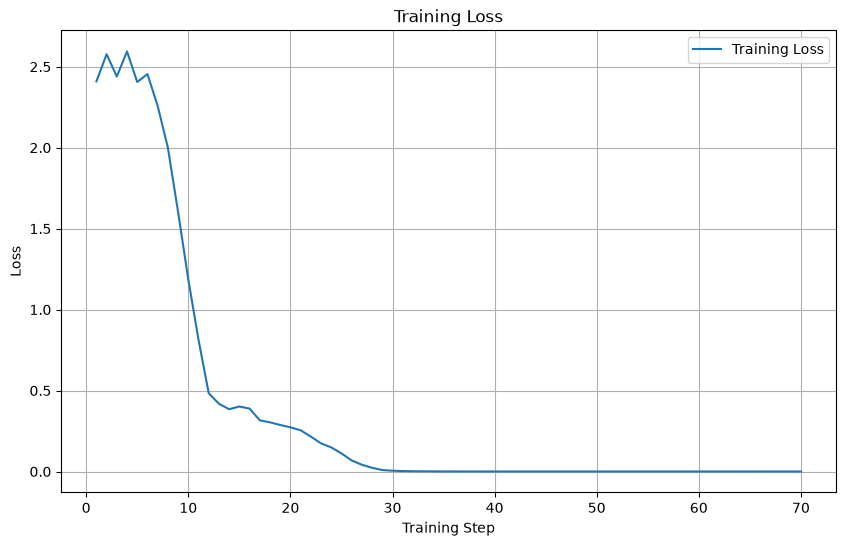

In [10]:
import matplotlib.pyplot as plt

def plot_loss(trainer, show_val=True):
    history = trainer.state.log_history

    train_steps = []
    train_loss = []
    val_steps = []
    val_loss = []

    for entry in history:
        if "loss" in entry and "step" in entry:
            train_steps.append(entry["step"])
            train_loss.append(entry["loss"])

        if show_val and "eval_loss" in entry and "step" in entry:
            val_steps.append(entry["step"])
            val_loss.append(entry["eval_loss"])

    plt.figure(figsize=(10, 6))

    plt.plot(train_steps, train_loss, label="Training Loss")

    if show_val and val_loss:
        plt.plot(val_steps, val_loss, label="Validation Loss")

    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.title("Training Loss" + (" vs. Validation Loss" if val_loss else ""))
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss(trainer, show_val=False)

In [12]:
from evaluation import (
    run_inference,
    add_predictions,
    calculate_metrics,
    print_report,
    save_metrics,
    save_confusion_matrix,
)

predictions = run_inference(
    model=model,
    processor=tokenizer,
    dataset=dataset["test"],
    system_prompt=SYSTEM_PROMPT,
    batch_size=8,
)

predictions = add_predictions(
    predictions,
    threshold=0.5,
)

metrics = calculate_metrics(
    predictions
)

print_report(metrics)

save_metrics(
    metrics,
    "../results/overfit-metrics.json",
)

save_confusion_matrix(
    metrics,
    "../results/overfit-confusion_matrix.png",
)


              BINARY CLASSIFIER EVALUATION

Examples evaluated: 432

METRICS
------------------------------------------------------------
Accuracy:            100.00%
Precision:           100.00%
Recall:              100.00%
False Positive Rate: 0.00%

CONFUSION MATRIX
------------------------------------------------------------
True negatives:  216
False positives: 0
False negatives: 0
True positives:  216




## Full Fine-Tuning Run
```
base:       Qwen 3.5 0.8B
quant:      4-bit NF4
compute:    BF16
LoRA rank:  16
LoRA dtype: BF16
```

## HYPERPARAMETER TEST: Batch Size

In [ ]:
import gc
import torch
import matplotlib.pyplot as plt
from unsloth import FastLanguageModel

# Batch sizes you want to evaluate
batch_sizes_to_test = [1, 2, 4, 8]
results = {}

base_model_name = "unsloth/Qwen3.5-0.8B"

for bs in batch_sizes_to_test:
    print(f"\n--- Starting experiment with per_device_train_batch_size = {bs} ---")

    # 1. Load fresh base model and tokenizer
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=base_model_name,
        max_seq_length=max_seq_length,
        load_in_4bit=True,
    )

    # 2. Add LoRA adapters
    model = FastLanguageModel.get_peft_model(
        model,
        r=8,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        lora_alpha=8,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=8,
        max_seq_length=max_seq_length,
    )

    # 3. Configure trainer with the test batch size
    trainer = SFTTrainer(
        model=model,
        train_dataset=dataset["train"],
        tokenizer=tokenizer,
        formatting_func=formatting_func,
        args=SFTConfig(
            max_seq_length=max_seq_length,
            per_device_train_batch_size=bs,
            gradient_accumulation_steps=4,
            warmup_steps=10,
            max_steps=100,
            logging_steps=1,
            output_dir=f"outputs_bs_{bs}",
            optim="adamw_8bit",
            seed=3407,
            dataset_num_proc=1,
        ),
    )

    trainer.train()

    # 4. Save history for this run
    steps = [entry["step"] for entry in trainer.state.log_history if "loss" in entry]
    losses = [entry["loss"] for entry in trainer.state.log_history if "loss" in entry]
    results[f"Batch Size {bs}"] = (steps, losses)

    # 5. Clear GPU VRAM memory for the next iteration
    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

# 6. Plot all batch size results on one comparison chart
plt.figure(figsize=(12, 6))

for label, (steps, losses) in results.items():
    plt.plot(steps, losses, label=label, linewidth=2)

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss Comparison Across Batch Sizes")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

For serving model on vLLM
```bash
export VLLM_ALLOW_RUNTIME_LORA_UPDATING=True

vllm serve Qwen/Qwen3.5-0.8B \
    --enable-lora \
    --max-loras 4 \
    --max-lora-rank 64
```

To load an adapter inot the LoRA pool:
```bash
curl -X POST http://localhost:8000/v1/load_lora_adapter \
  -H "Content-Type: application/json" \
  -d '{
    "lora_name": "customer_support",
    "lora_path": "/absolute/path/to/lora_adapters/echobot_1"
  }'
```

To unload an adapter inot the LoRA pool:
```bash
curl -X POST http://localhost:8000/v1/unload_lora_adapter \
  -H "Content-Type: application/json" \
  -d '{
    "lora_name": "echobot_1"
  }'
```

To select model use:
```bash
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:8000/v1",
    api_key="EMPTY",
)

response = client.chat.completions.create(
    model="Qwen/Qwen3.5-0.8B",
    messages=[
        {
            "role": "user",
            "content": "Explain our refund policy."
        }
    ],
    extra_body={
        "lora_name": "customer_support"
    },
)

print(response.choices[0].message.content)
```